# Hypothesis Testing

We are going to simulate 250 coin tosses, and try to get an idea of hypothesis testing.

## Flipping coins

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation as mad
from statadict import parse_stata_dict

We create our simulation function first.

In [2]:
def simulate_flips(n):
    return np.random.choice(["H", "T"], size=n)

Then we simulate 250 coin flips, substract it from the expected value. And do all these steps 1000 times.

In [3]:
simulated_states = [
    ((250 * 0.5) - np.count_nonzero(simulate_flips(250) == "H")) for i in range(1001)
]

As you can see, MAD is not much for a fair coin flip simulation.

In [4]:
mad(simulated_states)

np.float64(5.0)

In [5]:
heads = 140
tails = 110
mad_of_experiment = np.abs((250 * 0.5) - heads)
mad_of_experiment

np.float64(15.0)

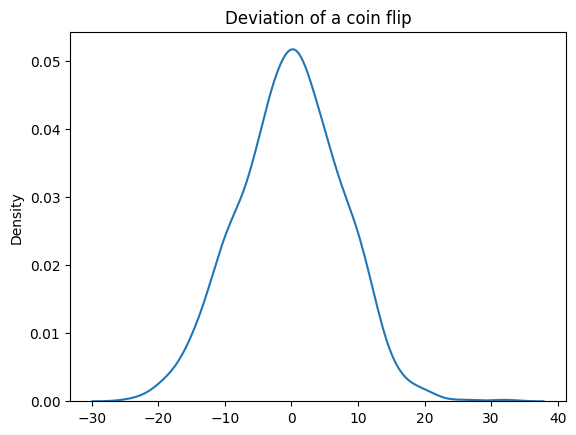

In [6]:
fig, ax = plt.subplots()
sns.kdeplot(simulated_states, ax=ax)
ax.set_title("Deviation of a coin flip")
plt.show()

For an experiment where 140 out of 250 coin tosses came up heads, MAD increases. What does it mean? We don't know yet, but we're going to learn it in the next section.

For this chapter, the only important part is to grasp that hypothesis test is a process consists of certain steps.

1. We start with an observation (140H, 110T), and the hypothesis that coin is biased.
2. We choose a test statistic that quanitifes the size of the observed effect. In this example, it's the absolute deviation from the expected outcome.
3. We define a null hypothesis, which is a model based on the assumption that the observed effect is due to chance, in other word, coin is fair.
4. Next, we compute the p-value, which is the probability of seeing the observed effect if the null hypothesis is true.

So we only need: **a test statistic**, **a null hypothesis**, and a **p-value** to formulate a hypothesis test.

## Testing a difference in means

Welcome our good old NSFG dataset.

In [7]:
preg = pd.read_csv("./data/2002FemPreg.csv.xz", compression="xz")
preg

,Unnamed: 0,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,...,poverty_i,laborfor_i,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw
0,0,1,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
1,1,1,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
2,2,2,1,NaN,NaN,NaN,NaN,5.0,NaN,3.0,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
3,3,2,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
4,4,2,3,NaN,NaN,NaN,NaN,6.0,NaN,1.0,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13588,13588,12571,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,...,0,0,0,0,4670.540953,5795.692880,6269.200989,1,78,1227
13589,13589,12571,2,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,0,0,0,0,4670.540953,5795.692880,6269.200989,1,78,1227
13590,13590,12571,3,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,0,0,0,0,4670.540953,5795.692880,6269.200989,1,78,1227
13591,13591,12571,4,NaN,NaN,NaN,NaN,6.0,NaN,1.0,...,0,0,0,0,4670.540953,5795.692880,6269.200989,1,78,1227


> Will continue